### Importing the Modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, confusion_matrix, classification_report, recall_score, f1_score, precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import RidgeClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

### Reading and Analyzing of the Datasets

In [2]:
heart_dataset1 = pd.read_csv("Heart Attack Data Set.csv")
df = heart_dataset1.copy()
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.describe().T.style.format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
age,303.00,54.37,9.08,29.00,47.50,55.00,61.00,77.00
sex,303.00,0.68,0.47,0.00,0.00,1.00,1.00,1.00
cp,303.00,0.97,1.03,0.00,0.00,1.00,2.00,3.00
trestbps,303.00,131.62,17.54,94.00,120.00,130.00,140.00,200.00
chol,303.00,246.26,51.83,126.00,211.00,240.00,274.50,564.00
fbs,303.00,0.15,0.36,0.00,0.00,0.00,0.00,1.00
restecg,303.00,0.53,0.53,0.00,0.00,1.00,1.00,2.00
thalach,303.00,149.65,22.91,71.00,133.50,153.00,166.00,202.00
exang,303.00,0.33,0.47,0.00,0.00,0.00,1.00,1.00
oldpeak,303.00,1.04,1.16,0.00,0.00,0.80,1.60,6.20


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [6]:
for i in list(df.columns):
    print("{} -- {}".format(i, df[i].value_counts().shape[0]))

age -- 41
sex -- 2
cp -- 4
trestbps -- 49
chol -- 152
fbs -- 2
restecg -- 3
thalach -- 91
exang -- 2
oldpeak -- 40
slope -- 3
ca -- 5
thal -- 4
target -- 2


### Dropping Duplicates

In [7]:
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


### Outlier Detection

In [8]:
numeric_list = ["age", "trestbps", "chol", "thalach", "oldpeak"]
df_numeric = df.loc[:, numeric_list]
df_numeric.head()

,age,trestbps,chol,thalach,oldpeak
0,63,145,233,150,2.3
1,37,130,250,187,3.5
2,41,130,204,172,1.4
3,56,120,236,178,0.8
4,57,120,354,163,0.6


In [9]:
df_numeric.describe().T

,count,mean,std,min,25%,50%,75%,max
age,302.0,54.420530,9.047970,29.0,48.00,55.5,61.00,77.0
trestbps,302.0,131.602649,17.563394,94.0,120.00,130.0,140.00,200.0
chol,302.0,246.500000,51.753489,126.0,211.00,240.5,274.75,564.0
thalach,302.0,149.569536,22.903527,71.0,133.25,152.5,166.00,202.0
oldpeak,302.0,1.043046,1.161452,0.0,0.00,0.8,1.60,6.2


In [10]:
# outlier detection
for i in numeric_list:
    
    # IQR
    Q1 = np.percentile(df.loc[:, i],25)
    Q3 = np.percentile(df.loc[:, i],75)
    
    IQR = Q3 - Q1
    
    print("Old shape: ", df.loc[:, i].shape)
    
    # upper bound
    upper = np.where(df.loc[:, i] >= (Q3 + 1.5 * IQR))
    
    # lower bound
    lower = np.where(df.loc[:, i] <= (Q1 - 1.5 * IQR))
    
    print("{} -- {}".format(upper, lower))
    
    try:
        df.drop(upper[0], inplace = True)
    except: print("KeyError: {} not found in axis".format(upper[0]))
    
    try:
        df.drop(lower[0], inplace = True)
    except:  print("KeyError: {} not found in axis".format(lower[0]))
        
    print("New shape: ", df.shape)

Old shape:  (302,)
(array([], dtype=int64),) -- (array([], dtype=int64),)
New shape:  (302, 14)
Old shape:  (302,)
(array([  8, 101, 110, 152, 194, 202, 222, 227, 240, 247, 259, 265, 291],
      dtype=int64),) -- (array([], dtype=int64),)
New shape:  (289, 14)
Old shape:  (289,)
(array([ 27,  84,  95, 213, 236], dtype=int64),) -- (array([], dtype=int64),)
New shape:  (284, 14)
Old shape:  (284,)
(array([], dtype=int64),) -- (array([228, 254, 278], dtype=int64),)
New shape:  (281, 14)
Old shape:  (281,)
(array([194, 209, 210, 211, 233, 273], dtype=int64),) -- (array([], dtype=int64),)
KeyError: [194 209 210 211 233 273] not found in axis
New shape:  (281, 14)


### Categorical Feature Analysis

In [11]:
categorical_list = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal", "target"]

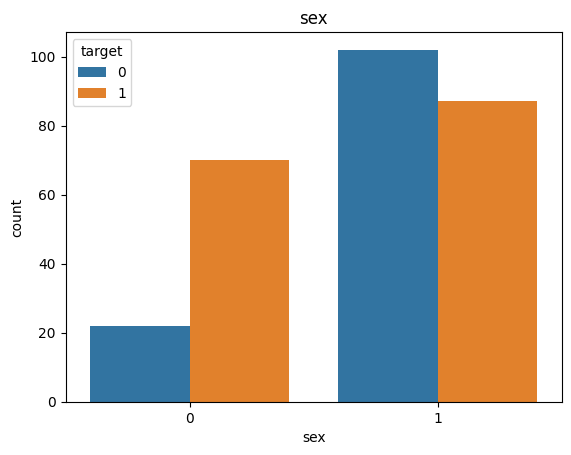

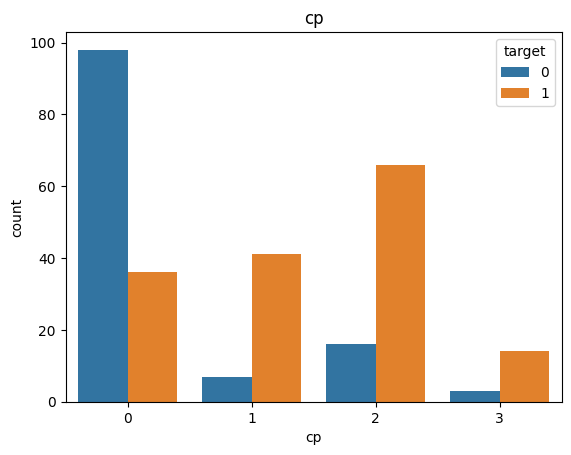

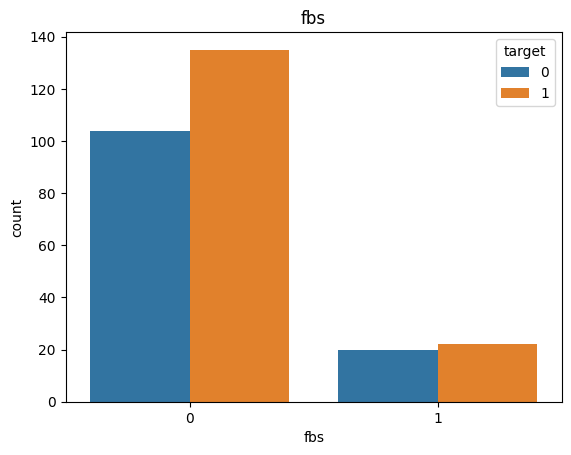

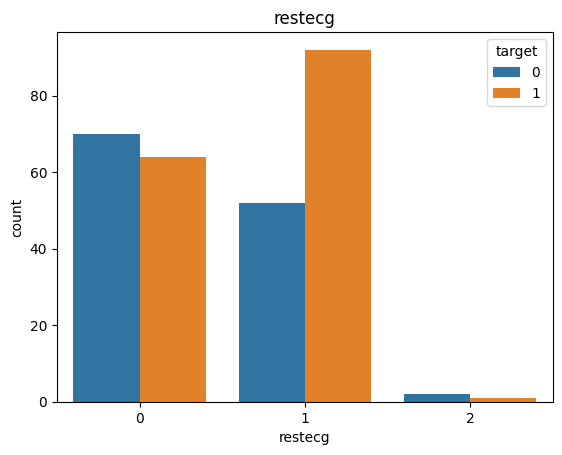

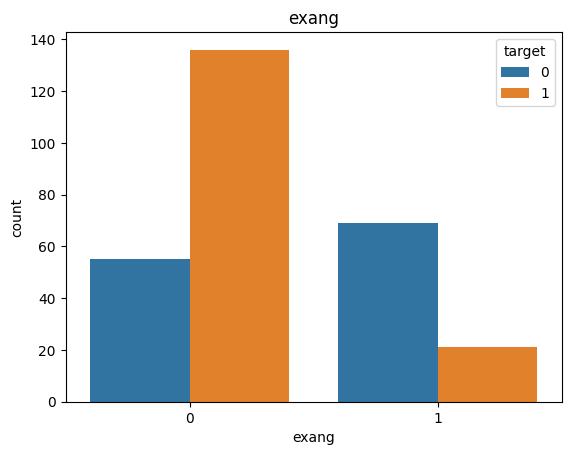

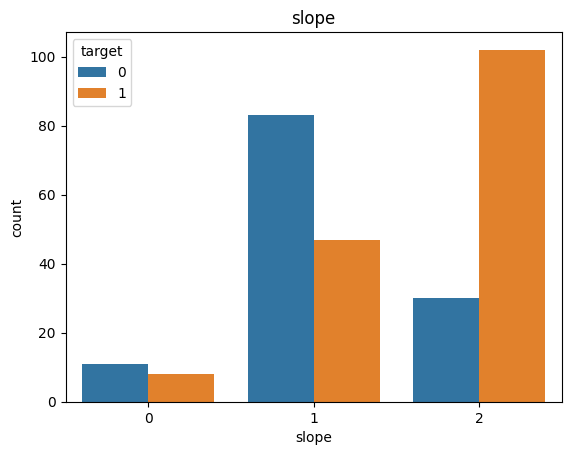

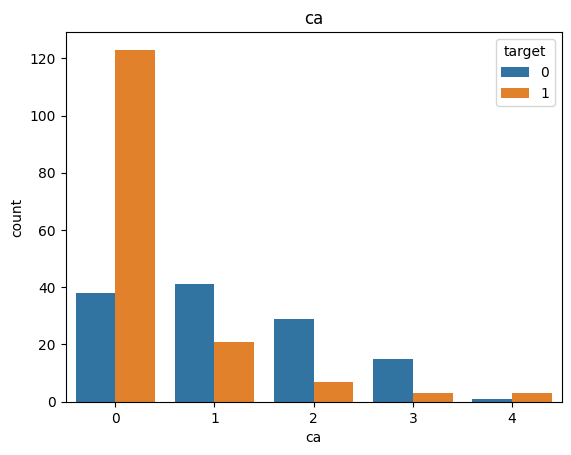

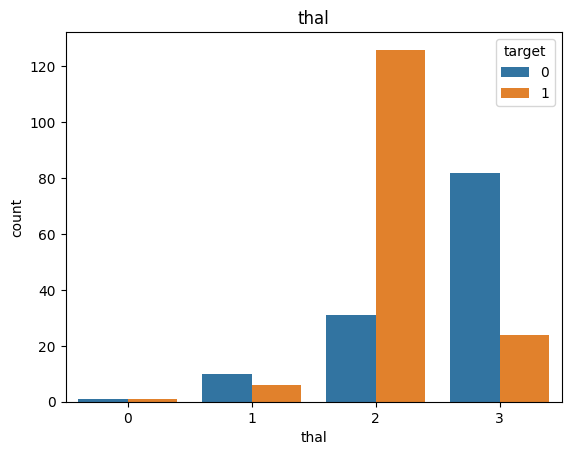

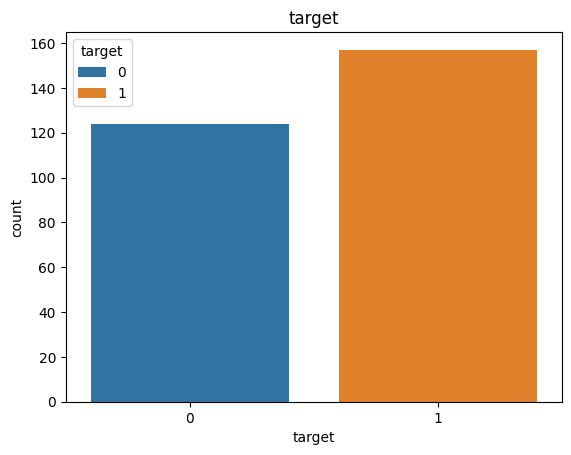

In [12]:
df_categoric = df.loc[:, categorical_list]
for i in categorical_list:
    plt.figure()
    sns.countplot(x = i, data = df_categoric, hue = "target")
    plt.title(i)

### Numeric Feature Analysis

In [13]:
numeric_list = ["age", "trestbps", "chol", "thalach", "oldpeak", "target"]

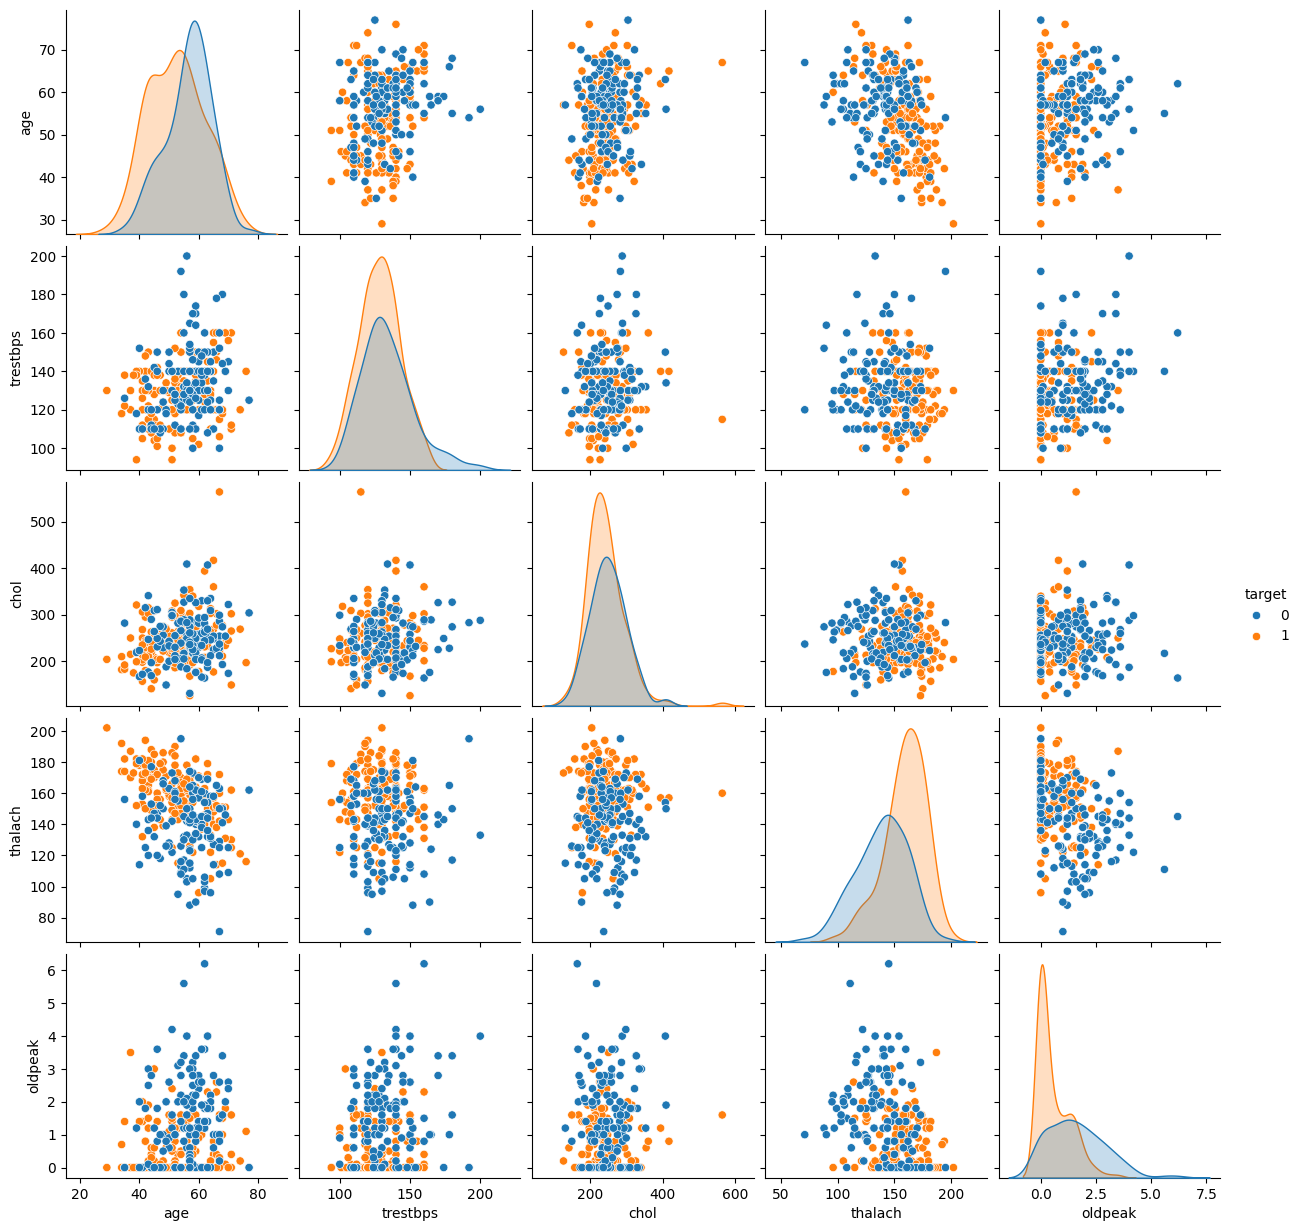

In [14]:
df_numeric = df.loc[:, numeric_list]
sns.pairplot(data = df_numeric, hue = "target", diag_kind = "kde")

### Boxplot Analysis

In [15]:
df_dummy = pd.DataFrame(df, columns= numeric_list[:-2])
df_dummy.head()

,age,trestbps,chol,thalach
0,63,145,233,150
1,37,130,250,187
2,41,130,204,172
3,56,120,236,178
4,57,120,354,163


In [16]:
df_dummy = pd.concat([df_dummy, df.loc[:, "target"]], axis = 1)
df_dummy.head()

,age,trestbps,chol,thalach,target
0,63,145,233,150,1
1,37,130,250,187,1
2,41,130,204,172,1
3,56,120,236,178,1
4,57,120,354,163,1


In [17]:
data_melted = pd.melt(df_dummy, id_vars = "target", var_name = "features", value_name = "value")
data_melted.head(20)

,target,features,value
0,1,age,63
1,1,age,37
2,1,age,41
3,1,age,56
4,1,age,57
5,1,age,57
6,1,age,56
7,1,age,44
8,1,age,57
9,1,age,54


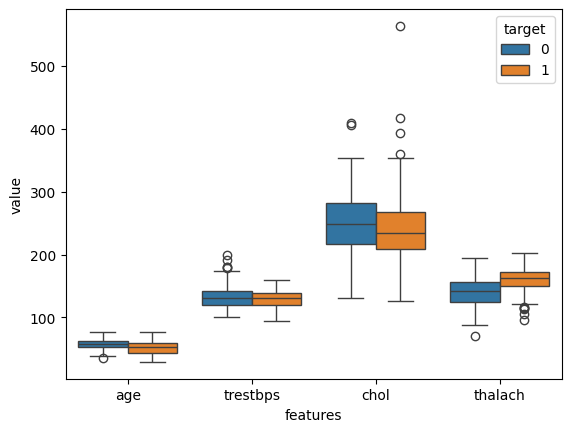

In [18]:
plt.figure()
sns.boxplot(x = "features", y = "value", hue = "target", data = data_melted)
plt.show();

### Swarmplot Analysis

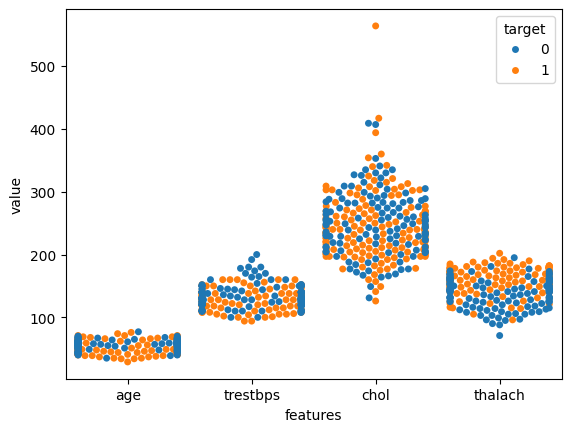

In [19]:
plt.figure()
sns.swarmplot(x = "features", y = "value", hue = "target", data = data_melted)
plt.show();

### Catplot Analysis

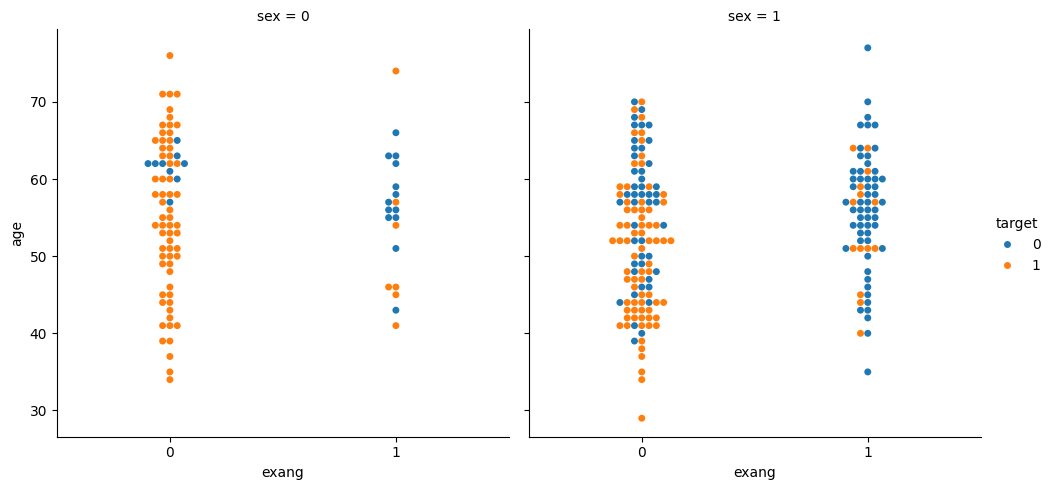

In [20]:
sns.catplot(x = "exang", y = "age", hue = "target", col = "sex", kind = "swarm", data = df)
plt.show();

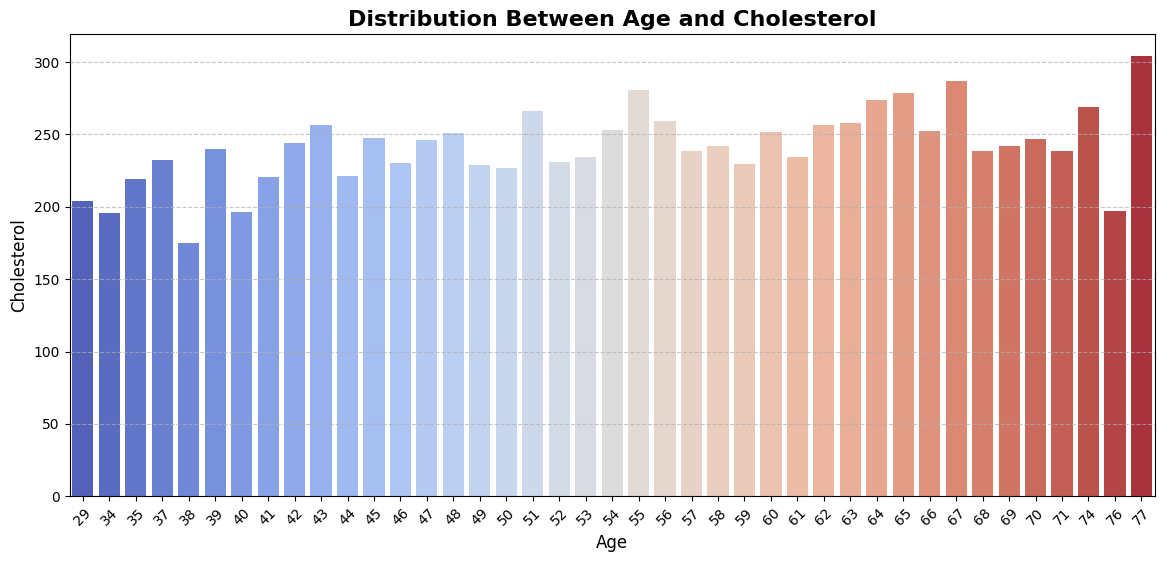

In [21]:
#distribution between age and cholestoral
plt.figure(figsize=(14,6))
sns.barplot(x="age", y="chol", data=df, palette="coolwarm", ci=None)
plt.title("Distribution Between Age and Cholesterol", fontsize=16, weight="bold")
plt.xlabel("Age", fontsize=12)
plt.ylabel("Cholesterol", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


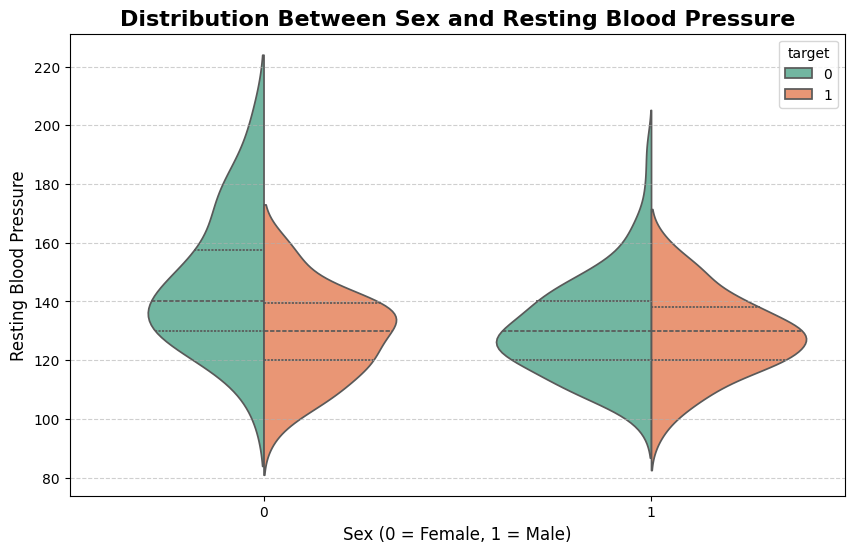

In [22]:
#distribution between sex and resting blood pressure
plt.figure(figsize=(10,6))
sns.violinplot(
    x="sex", 
    y="trestbps", 
    hue="target", 
    data=df, 
    palette="Set2",   
    split=True,       
    inner="quartile"  
)
plt.title("Distribution Between Sex and Resting Blood Pressure", fontsize=16, weight="bold")
plt.xlabel("Sex (0 = Female, 1 = Male)", fontsize=12)
plt.ylabel("Resting Blood Pressure", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

### Checking Correlations

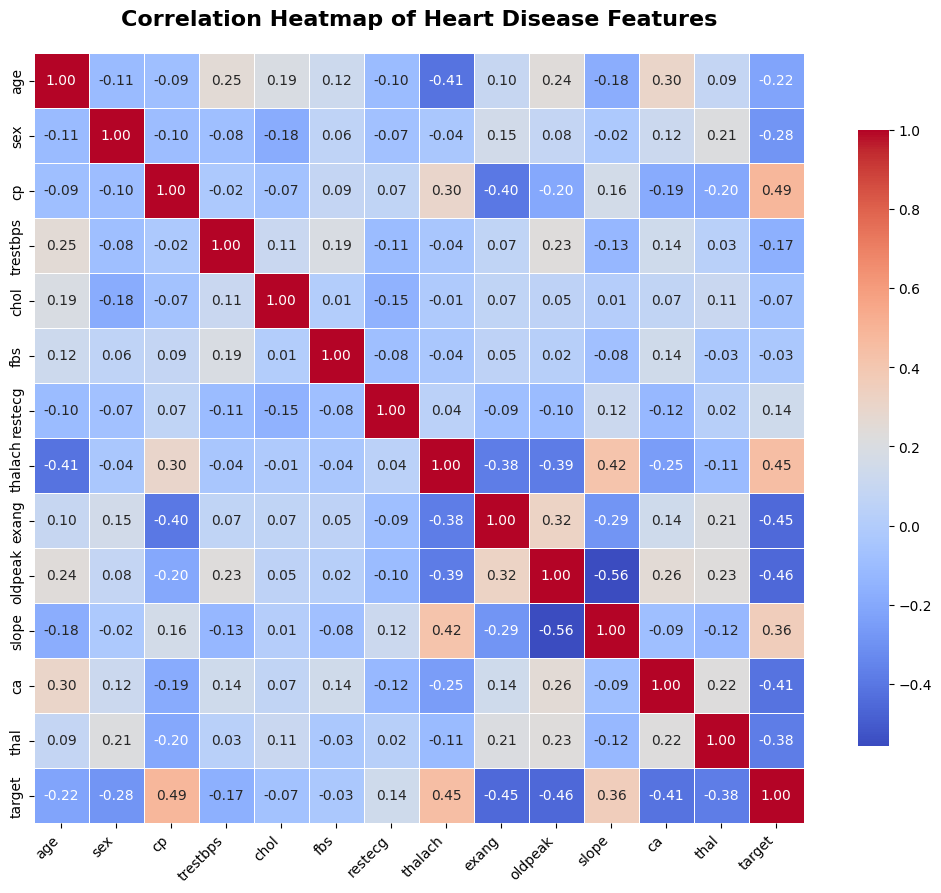

In [23]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    df.corr(), 
    annot=True, 
    fmt=".2f", 
    linewidths=.7, 
    cmap="coolwarm",      
    cbar_kws={'shrink': 0.8},  
    square=True           
)
plt.title("Correlation Heatmap of Heart Disease Features", fontsize=16, weight="bold", pad=20)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.show()

### Modelling

In [24]:
model_df = df.copy()

In [25]:
model_df = pd.get_dummies(model_df, columns= categorical_list[:-1], drop_first= True, dtype= float)

In [26]:
model_df.head()

,age,trestbps,chol,thalach,oldpeak,target,sex_1,cp_1,cp_2,cp_3,...,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,ca_4,thal_1,thal_2,thal_3
0,63,145,233,150,2.3,1,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,37,130,250,187,3.5,1,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,41,130,204,172,1.4,1,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,56,120,236,178,0.8,1,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,57,120,354,163,0.6,1,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [27]:
x = model_df.drop(['target'], axis= 1)
y = model_df[['target']]

### Train-Test Split

In [109]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.25, random_state= 42)
print("x_train: {}".format(x_train.shape))
print("x_test: {}".format(x_test.shape))
print("y_train: {}".format(y_train.shape))
print("y_test: {}".format(y_test.shape))

x_train: (210, 22)
x_test: (71, 22)
y_train: (210, 1)
y_test: (71, 1)


### Data Augmentation

In [110]:
SEED = 42
np.random.seed(SEED)

In [111]:
def augment_age(df, n_samples=100, seed=42):
    np.random.seed(seed)
    df_sample = df[(df["age"] >= 30) & (df["age"] <= 60)].sample(n=n_samples, replace=True, random_state=seed).copy()
    df_sample["age"] += np.random.choice([-1, 1], size=n_samples)
    return df_sample

In [112]:
def augment_chol(df, n_samples=100, seed=42):
    np.random.seed(seed)
    df_sample = df.sample(n=n_samples, replace=True, random_state=seed).copy()
    noise = np.random.randint(1, 6, size=n_samples)
    df_sample["chol"] += np.where(df_sample["target"] == 1, noise, -noise)
    return df_sample

In [113]:
def augment_trestbps(df, n_samples=100, seed=42):
    np.random.seed(seed)
    df_sample = df[df["trestbps"] <= 140].sample(n=n_samples, replace=True, random_state=seed).copy()
    noise = np.random.randint(-5, 6, size=n_samples)
    df_sample["trestbps"] += noise
    return df_sample

In [114]:
def augment_thalach(df, n_samples=100, seed=42):
    np.random.seed(seed)
    df_sample = df.sample(n=n_samples, replace=True, random_state=seed).copy()
    noise = np.random.randint(-5, 6, size=n_samples)
    df_sample["thalach"] += noise
    return df_sample

In [115]:
def augment_oldpeak(df, n_samples=100, seed=42):
    np.random.seed(seed)
    df_sample = df.sample(n=n_samples, replace=True, random_state=seed).copy()
    noise = np.random.normal(loc=0, scale=0.1, size=n_samples)
    safe_mask = df_sample["oldpeak"] <= 1.0
    df_sample.loc[safe_mask, "oldpeak"] += noise[safe_mask]
    df_sample.loc[~safe_mask, "oldpeak"] += np.clip(noise[~safe_mask], -0.05, 0.05)
    return df_sample

In [116]:
train_df = x_train.copy()
train_df["target"] = y_train

augmented_df = pd.concat([
    augment_age(train_df, 100),
    augment_chol(train_df, 100),
    augment_trestbps(train_df, 100),
    augment_thalach(train_df, 100),
    augment_oldpeak(train_df, 100)
], ignore_index=True)

In [117]:
train_augmented = pd.concat([train_df, augmented_df], ignore_index=True)
x_train_augmented = train_augmented.drop("target", axis=1)
y_train_augmented = train_augmented[["target"]]

In [118]:
print("Size of original x_train dataset: ", x_train.shape)
print("Size of augmented x_train dataset:", x_train_augmented.shape)
print("Size of original y_train dataset: ", y_train.shape)
print("Size of augmented y_train dataset: ", y_train_augmented.shape)

Size of original x_train dataset:  (210, 22)
Size of augmented x_train dataset: (710, 22)
Size of original y_train dataset:  (210, 1)
Size of augmented y_train dataset:  (710, 1)


### Scaling

In [119]:
scaler = StandardScaler()
scaler

StandardScaler()

In [120]:
x_train_augmented = scaler.fit_transform(x_train_augmented)
x_test = scaler.transform(x_test)

### Logistic Regression

In [121]:
log = LogisticRegression()
log

LogisticRegression()

In [122]:
log_model = log.fit(x_train_augmented, y_train_augmented)

In [123]:
y_pred_log = log_model.predict(x_test)
print("Accuracy Rate of Logistic Regression Model => {}".format(accuracy_score(y_pred_log, y_test)))
print("Precision => {}".format(precision_score(y_test, y_pred_log)))
print("Recall => {}".format(recall_score(y_test, y_pred_log)))
print("F1-Score => {}".format(f1_score(y_test, y_pred_log)))
print(classification_report(y_pred_log, y_test))
print()
print("Confusion Matrix => \n", confusion_matrix(y_test, y_pred_log))

Accuracy Rate of Logistic Regression Model => 0.8028169014084507
Precision => 0.9354838709677419
Recall => 0.7073170731707317
F1-Score => 0.8055555555555556
              precision    recall  f1-score   support

           0       0.93      0.70      0.80        40
           1       0.71      0.94      0.81        31

    accuracy                           0.80        71
   macro avg       0.82      0.82      0.80        71
weighted avg       0.83      0.80      0.80        71


Confusion Matrix => 
 [[28  2]
 [12 29]]


### Roc Curve

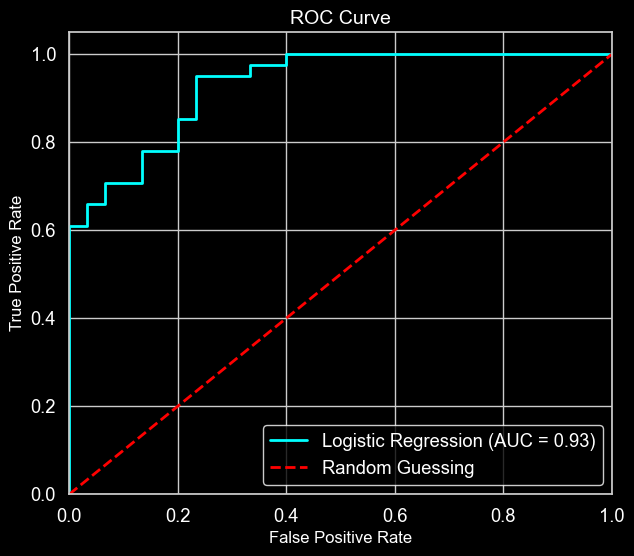

In [124]:
logit_roc_auc = roc_auc_score(y_test, log_model.predict_proba(x_test)[:, 1])
fpr, tpr, thresholds = roc_curve(y_test, log_model.predict_proba(x_test)[:, 1])

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color="cyan", lw=2, 
         label='Logistic Regression (AUC = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--", label="Random Guessing")

plt.gca().set_facecolor("black")
plt.gcf().patch.set_facecolor("black")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", color="white", fontsize=12)
plt.ylabel("True Positive Rate", color="white", fontsize=12)
plt.title("ROC Curve", color="white", fontsize=14)

plt.legend(loc="lower right", facecolor="black", edgecolor="white", labelcolor="white")
plt.tick_params(axis='x', colors='white')
plt.tick_params(axis='y', colors='white')

plt.show()

### KNN

In [125]:
knn = KNeighborsClassifier()
knn

KNeighborsClassifier()

In [126]:
knn_model = knn.fit(x_train_augmented, y_train_augmented)
knn_model

KNeighborsClassifier()

In [127]:
y_pred_knn = knn_model.predict(x_test)
print("Accuracy rate of KNN Model => {}".format(accuracy_score(y_test, y_pred_knn)))
print("Precision => {}".format(precision_score(y_test, y_pred_knn)))
print("Recall => {}".format(recall_score(y_test, y_pred_knn)))
print("F1-Score => {}".format(f1_score(y_test, y_pred_knn)))
print(classification_report(y_test, y_pred_knn))
print()
print("Confusion Matrix => \n", confusion_matrix(y_test, y_pred_knn))

Accuracy rate of KNN Model => 0.8309859154929577
Precision => 0.967741935483871
Recall => 0.7317073170731707
F1-Score => 0.8333333333333334
              precision    recall  f1-score   support

           0       0.72      0.97      0.83        30
           1       0.97      0.73      0.83        41

    accuracy                           0.83        71
   macro avg       0.85      0.85      0.83        71
weighted avg       0.87      0.83      0.83        71


Confusion Matrix => 
 [[29  1]
 [11 30]]


### SVM

In [128]:
svc = SVC(random_state= 42)
svc

SVC(random_state=42)

In [129]:
svc_model = svc.fit(x_train_augmented, y_train_augmented)
svc_model

SVC(random_state=42)

In [130]:
y_pred_svc = svc_model.predict(x_test)
print("Accuracy Rate of SVM Model => {}".format(accuracy_score(y_test, y_pred_svc)))
print("Precision => {}".format(precision_score(y_test, y_pred_svc)))
print("Recall => {}".format(recall_score(y_test, y_pred_svc)))
print("F1-Score => {}".format(f1_score(y_test, y_pred_svc)))
print(classification_report(y_pred_svc, y_test))
print("Confusion Matrix => \n", confusion_matrix(y_test, y_pred_svc))

Accuracy Rate of SVM Model => 0.8873239436619719
Precision => 0.9459459459459459
Recall => 0.8536585365853658
F1-Score => 0.8974358974358975
              precision    recall  f1-score   support

           0       0.93      0.82      0.88        34
           1       0.85      0.95      0.90        37

    accuracy                           0.89        71
   macro avg       0.89      0.88      0.89        71
weighted avg       0.89      0.89      0.89        71

Confusion Matrix => 
 [[28  2]
 [ 6 35]]


### Decision Tree

In [131]:
dt = DecisionTreeClassifier()
dt

DecisionTreeClassifier()

In [132]:
dt_model = dt.fit(x_train_augmented, y_train_augmented)
dt_model

DecisionTreeClassifier()

In [133]:
y_pred_dt = dt_model.predict(x_test)
print("Accuracy of Decision Tree Model => {}".format(accuracy_score(y_test, y_pred_dt)))
print("Precision => {}".format(precision_score(y_test, y_pred_dt)))
print("Recall => {}".format(recall_score(y_test, y_pred_dt)))
print("F1-Score => {}".format(f1_score(y_test, y_pred_dt)))
print(classification_report(y_test, y_pred_dt))
print()
print("Confusion Matrix => \n", confusion_matrix(y_test, y_pred_dt))

Accuracy of Decision Tree Model => 0.7183098591549296
Precision => 0.8387096774193549
Recall => 0.6341463414634146
F1-Score => 0.7222222222222222
              precision    recall  f1-score   support

           0       0.62      0.83      0.71        30
           1       0.84      0.63      0.72        41

    accuracy                           0.72        71
   macro avg       0.73      0.73      0.72        71
weighted avg       0.75      0.72      0.72        71


Confusion Matrix => 
 [[25  5]
 [15 26]]


### Random Forest

In [134]:
rf = RandomForestClassifier(random_state= 42)
rf

RandomForestClassifier(random_state=42)

In [135]:
rf_model = rf.fit(x_train_augmented, y_train_augmented)
rf_model

RandomForestClassifier(random_state=42)

In [136]:
y_pred_rf = rf_model.predict(x_test)
print("Accuracy Rate of Random Forest Model => {}".format(accuracy_score(y_test, y_pred_rf)))
print("Precision => {}".format(precision_score(y_test, y_pred_rf)))
print("Recall => {}".format(recall_score(y_test, y_pred_rf)))
print("F1-Score => {}".format(f1_score(y_test, y_pred_rf)))
print(classification_report(y_test, y_pred_rf))
print()
print("Confusion Matrix => \n", confusion_matrix(y_test, y_pred_rf))

Accuracy Rate of Random Forest Model => 0.8028169014084507
Precision => 0.8857142857142857
Recall => 0.7560975609756098
F1-Score => 0.8157894736842105
              precision    recall  f1-score   support

           0       0.72      0.87      0.79        30
           1       0.89      0.76      0.82        41

    accuracy                           0.80        71
   macro avg       0.80      0.81      0.80        71
weighted avg       0.82      0.80      0.80        71


Confusion Matrix => 
 [[26  4]
 [10 31]]


### Ridge

In [137]:
ridge = RidgeClassifier()
ridge

RidgeClassifier()

In [138]:
ridge_model = ridge.fit(x_train_augmented, y_train_augmented)
ridge_model

RidgeClassifier()

In [139]:
y_pred_ridge = ridge_model.predict(x_test)
print("Accuracy Rate of Ridge Model => {}".format(accuracy_score(y_test, y_pred_ridge)))
print("Precision => {}".format(precision_score(y_test, y_pred_ridge)))
print("Recall => {}".format(recall_score(y_test, y_pred_ridge)))
print("F1-Score => {}".format(f1_score(y_test, y_pred_ridge)))
print(classification_report(y_test, y_pred_ridge))
print()
print("Confussion Matrix => \n", confusion_matrix(y_test, y_pred_ridge))

Accuracy Rate of Ridge Model => 0.9154929577464789
Precision => 0.9487179487179487
Recall => 0.9024390243902439
F1-Score => 0.925
              precision    recall  f1-score   support

           0       0.88      0.93      0.90        30
           1       0.95      0.90      0.93        41

    accuracy                           0.92        71
   macro avg       0.91      0.92      0.91        71
weighted avg       0.92      0.92      0.92        71


Confussion Matrix => 
 [[28  2]
 [ 4 37]]


### Light GbM

In [140]:
lgbm = LGBMClassifier()
lgbm

LGBMClassifier()

In [141]:
lgbm_model = lgbm.fit(x_train_augmented, y_train_augmented)
lgbm_model

[LightGBM] [Info] Number of positive: 411, number of negative: 299
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000141 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 375
[LightGBM] [Info] Number of data points in the train set: 710, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.578873 -> initscore=0.318150
[LightGBM] [Info] Start training from score 0.318150
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

LGBMClassifier()

In [142]:
y_pred_lgbm = lgbm_model.predict(x_test)
print("Accuracy Rate of Light GBM Model => {}".format(accuracy_score(y_test, y_pred_lgbm)))
print("Precision => {}".format(precision_score(y_test, y_pred_lgbm)))
print("Recall => {}".format(recall_score(y_test, y_pred_lgbm)))
print("F1-Score => {}".format(f1_score(y_test, y_pred_lgbm)))
print(classification_report(y_test, y_pred_lgbm))
print()
print("Confusion Matrix => \n", confusion_matrix(y_test, y_pred_lgbm))

Accuracy Rate of Light GBM Model => 0.7887323943661971
Precision => 0.8823529411764706
Recall => 0.7317073170731707
F1-Score => 0.8
              precision    recall  f1-score   support

           0       0.70      0.87      0.78        30
           1       0.88      0.73      0.80        41

    accuracy                           0.79        71
   macro avg       0.79      0.80      0.79        71
weighted avg       0.81      0.79      0.79        71


Confusion Matrix => 
 [[26  4]
 [11 30]]


### XGBoost

In [143]:
xgb = XGBClassifier()
xgb

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [144]:
xgb_model = xgb.fit(x_train_augmented, y_train_augmented)
xgb_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [145]:
y_pred_xgb = xgb_model.predict(x_test)
print("Accuracy Score of XGBoost Model => {}".format(accuracy_score(y_test, y_pred_xgb)))
print("Precision => {}".format(precision_score(y_test, y_pred_xgb)))
print("Recall => {}".format(recall_score(y_test, y_pred_xgb)))
print("F1-Score => {}".format(f1_score(y_test, y_pred_xgb)))
print(classification_report(y_test, y_pred_xgb))
print()
print("Confusion Matrix => \n", confusion_matrix(y_test, y_pred_xgb))

Accuracy Score of XGBoost Model => 0.7464788732394366
Precision => 0.7948717948717948
Recall => 0.7560975609756098
F1-Score => 0.775
              precision    recall  f1-score   support

           0       0.69      0.73      0.71        30
           1       0.79      0.76      0.78        41

    accuracy                           0.75        71
   macro avg       0.74      0.74      0.74        71
weighted avg       0.75      0.75      0.75        71


Confusion Matrix => 
 [[22  8]
 [10 31]]


## Model Tuning

### Logistic Regression

In [67]:
log_params = {
    "penalty": ['l1', 'l2'],
    "C": [0.0001, 0.01, 0.1, 1, 10, 100]
}

In [68]:
log_model_cv = GridSearchCV(log, log_params, cv= 10)
log_model_cv.fit(x_train, y_train)

GridSearchCV(cv=10, estimator=LogisticRegression(),
             param_grid={'C': [0.0001, 0.01, 0.1, 1, 10, 100],
                         'penalty': ['l1', 'l2']})

In [69]:
print("Best parameters: " + str(log_model_cv.best_params_))

Best parameters: {'C': 1, 'penalty': 'l2'}


In [70]:
log_tuned = LogisticRegression(C= 1, penalty= 'l2')
log_model_tuned = log_tuned.fit(x_train_augmented, y_train_augmented)
log_model_tuned

LogisticRegression(C=1)

In [71]:
y_pred_log_tuned = log_model_tuned.predict(x_test)
print("Accuracy Rate of Tuned Model => {}".format(accuracy_score(y_test, y_pred_log_tuned)))
print("Previous Accuracy => {}".format(accuracy_score(y_test, y_pred_log)))

Accuracy Rate of Tuned Model => 0.9310344827586207
Previous Accuracy => 0.9310344827586207


### KNN

In [72]:
nlist = []
for i in range(1, 11):
    nlist.append(i)

knn_params = {
    "n_neighbors": nlist,
    "weights": ['uniform', 'distance']
}

In [73]:
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, param_grid= knn_params, cv= 10)
knn_cv.fit(x_train_augmented, y_train_augmented)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'weights': ['uniform', 'distance']})

In [74]:
print(knn_cv.best_params_)

{'n_neighbors': 8, 'weights': 'distance'}


In [75]:
knn_tuned = KNeighborsClassifier(n_neighbors= 8, weights= "distance")
knn_model_tuned = knn_tuned.fit(x_train_augmented, y_train_augmented)
knn_model_tuned

KNeighborsClassifier(n_neighbors=8, weights='distance')

In [ ]:
y_pred_knn_tuned = knn_model_tuned.predict(x_test)
print("Accuracy rate of tuned model => {}".format(accuracy_score(y_test, y_pred_knn_tuned)))
print("Previous accuracy => {}".format(accuracy_score(y_test, y_pred_knn_tuned)))

Accuracy rate of tuned model => 0.7931034482758621
Precious accuracy 0.7931034482758621


### SVM

In [78]:
svm_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma' : ['scale', 'auto']
}

In [79]:
svm = SVC()
svm_cv = GridSearchCV(svm, param_grid= svm_params, cv = 10, n_jobs= -1, verbose= 2)
svm_cv.fit(x_train_augmented, y_train_augmented)

Fitting 10 folds for each of 40 candidates, totalling 400 fits


GridSearchCV(cv=10, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly', 'sigmoid']},
             verbose=2)

In [80]:
print(svm_cv.best_params_)

{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [81]:
svm_tuned = SVC(C= 10, kernel= 'rbf', gamma= 'scale')
svc_model_tuned = svm_tuned.fit(x_train_augmented, y_train_augmented)
svc_model_tuned

SVC(C=10)

In [82]:
y_pred_svc_tuned = svc_model_tuned.predict(x_test)
print("Accuracy of tuned model => {}".format(accuracy_score(y_test, y_pred_svc_tuned)))
print("Previous accuracy => {}".format(accuracy_score(y_test, y_pred_svc)))

Accuracy of tuned model => 0.8275862068965517
Previous accuracy => 0.8275862068965517


### Decision Tree

In [83]:
dt_params = {"max_depth": np.arange(2, 11),
             "max_features": np.arange(2, 15),
             "min_samples_split": [2, 5, 10, 20]}

In [84]:
dt = DecisionTreeClassifier()
dt_cv = GridSearchCV(dt, param_grid= dt_params, cv = 10, n_jobs= -1, verbose= 2)
dt_cv.fit(x_train_augmented, y_train_augmented)

Fitting 10 folds for each of 468 candidates, totalling 4680 fits


GridSearchCV(cv=10, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'max_depth': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10]),
                         'max_features': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
                         'min_samples_split': [2, 5, 10, 20]},
             verbose=2)

In [85]:
print(dt_cv.best_params_)

{'max_depth': 10, 'max_features': 11, 'min_samples_split': 5}


In [86]:
dt_tuned = DecisionTreeClassifier(max_depth= 10, max_features= 10, min_samples_split= 5)
dt_model_tuned = dt_tuned.fit(x_train_augmented, y_train_augmented)
dt_model_tuned

DecisionTreeClassifier(max_depth=10, max_features=10, min_samples_split=5)

In [ ]:
y_pred_dt_tuned = dt_model_tuned.predict(x_test)
print("Accuracy of tuned model => {}".format(accuracy_score(y_test, y_pred_dt_tuned)))
print("Previous Accuracy => {}".format(accuracy_score(y_test, y_pred_dt)))

Accuracy of tuned model => 0.8620689655172413
Precious Accuracy => 0.7931034482758621


### Random Forest

In [88]:
rf_params = {
    "max_depth": np.arange(2, 11),
    "max_features": np.arange(2, 15),
    "n_estimators": [10, 50, 100, 250, 500, 1000],
    "min_samples_split": [2, 5, 10, 20]
}
rf = RandomForestClassifier()
rf_cv = GridSearchCV(rf, param_grid= rf_params, cv = 10, n_jobs= -1, verbose= 2)
rf_cv.fit(x_train, y_train)

Fitting 10 folds for each of 2808 candidates, totalling 28080 fits


GridSearchCV(cv=10, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10]),
                         'max_features': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
                         'min_samples_split': [2, 5, 10, 20],
                         'n_estimators': [10, 50, 100, 250, 500, 1000]},
             verbose=2)

In [89]:
print(rf_cv.best_params_)

{'max_depth': 9, 'max_features': 2, 'min_samples_split': 10, 'n_estimators': 250}


In [92]:
rf_tuned = RandomForestClassifier(max_depth= 9, max_features= 2, min_samples_split= 10, n_estimators= 250)
rf_model_tuned = rf_tuned.fit(x_train, y_train)
rf_model_tuned

RandomForestClassifier(max_depth=9, max_features=2, min_samples_split=10,
                       n_estimators=250)

In [93]:
y_pred_rf_tuned = rf_model_tuned.predict(x_test)
print("Accuracy rate of tuned model => {}".format(accuracy_score(y_test, y_pred_rf_tuned)))
print("Previous accuracy => {}".format(accuracy_score(y_test, y_pred_rf)))

Accuracy rate of tuned model => 0.8620689655172413
Previous accuracy => 0.8275862068965517


### LightGBM

In [94]:
lgbm_params = {
    "n_estimators": [50, 100, 200, 500],
    "learning_rate": [0.01, 0.1, 0.02, 0.05],
    "max_depth": [-1, 0, 1, 2],
    "num_leaves": [10, 20, 31, 40, 50],
    "subsample": [0.5, 1.0, 1.5, 2]
}
lgbm = LGBMClassifier()
lgbm_cv = GridSearchCV(lgbm, param_grid= lgbm_params, cv= 10, n_jobs= -1, verbose= 2)
lgbm_cv.fit(x_train, y_train)

Fitting 10 folds for each of 1280 candidates, totalling 12800 fits
[LightGBM] [Info] Number of positive: 140, number of negative: 112
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000300 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 240
[LightGBM] [Info] Number of data points in the train set: 252, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.555556 -> initscore=0.223144
[LightGBM] [Info] Start training from score 0.223144
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM

GridSearchCV(cv=10, estimator=LGBMClassifier(), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.02, 0.05],
                         'max_depth': [-1, 0, 1, 2],
                         'n_estimators': [50, 100, 200, 500],
                         'num_leaves': [10, 20, 31, 40, 50],
                         'subsample': [0.5, 1.0, 1.5, 2]},
             verbose=2)

In [95]:
print(lgbm_cv.best_params_)

{'learning_rate': 0.1, 'max_depth': 1, 'n_estimators': 200, 'num_leaves': 10, 'subsample': 0.5}


In [96]:
lgbm_tuned = LGBMClassifier(learning_rate= 0.1, max_depth= 1, n_estimators= 200, num_leaves= 10, subsample= 0.5)
lgbm_model_tuned = lgbm_tuned.fit(x_train, y_train)
lgbm_model_tuned

[LightGBM] [Info] Number of positive: 140, number of negative: 112
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000153 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 240
[LightGBM] [Info] Number of data points in the train set: 252, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.555556 -> initscore=0.223144
[LightGBM] [Info] Start training from score 0.223144
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

LGBMClassifier(max_depth=1, n_estimators=200, num_leaves=10, subsample=0.5)

In [97]:
y_pred_lgbm_tuned = lgbm_model_tuned.predict(x_test)
print("Accuracy rate of tuned model {}".format(accuracy_score(y_test, y_pred_lgbm_tuned)))
print("Previous accuracy => {}".format(accuracy_score(y_test, y_pred_lgbm)))

Accuracy rate of tuned model 0.8275862068965517
Previous accuracy => 0.896551724137931


### XGboost

In [98]:
xgb_params = {
    "n_estimators": [50, 100, 500, 1000, 5000],
    "subsample": [0.6, 0.8, 1.0, 2.0],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.1, 0.2, 0.3, 0.4, 0.5],
    "min_sample_split": [2, 5, 10]
}
xgb = XGBClassifier()
xgb_cv = GridSearchCV(xgb, param_grid= xgb_params, cv= 10, n_jobs= -1, verbose = 2)
xgb_cv.fit(x_train, y_train)

Fitting 10 folds for each of 1200 candidates, totalling 12000 fits


GridSearchCV(cv=10,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.1, 0.2, 0.3, 0.4, 0.5],
                         'max_depth': [4, 6, 8, 10],
                         'min_sample_split': [2, 5, 10],
                         'n_estimators': [50, 100, 500, 1000, 5000],
                         'subsample': [0.6, 0.8, 1.0, 2.0]},
             verbose=2)

In [99]:
print(xgb_cv.best_params_)

{'learning_rate': 0.2, 'max_depth': 4, 'min_sample_split': 2, 'n_estimators': 50, 'subsample': 0.8}


In [101]:
xgb_tuned = XGBClassifier(learning_rate = 0.2, max_depth = 4, min_sample_split = 2, n_estimators = 50, subsample = 0.8)
xgb_model_tuned = xgb_tuned.fit(x_train, y_train)
xgb_model_tuned

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, min_sample_split=2, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=None, num_parallel_tree=None, ...)

In [102]:
y_pred_xgb_tuned = xgb_model_tuned.predict(x_test)
print("Accuracy rate of tuned model => {}".format(accuracy_score(y_test, y_pred_xgb_tuned)))
print("Previous accuracy => {}".format(accuracy_score(y_test, y_pred_xgb)))

Accuracy rate of tuned model => 0.5862068965517241
Previous accuracy => 0.8620689655172413


### Model Comparison

In [67]:
log_score = accuracy_score(y_test, y_pred_log) * 100
knn_score = accuracy_score(y_test, y_pred_knn) * 100
svm_score = accuracy_score(y_test, y_pred_svc) * 100
dt_score = accuracy_score(y_test, y_pred_dt) * 100
rf_score = accuracy_score(y_test, y_pred_rf) * 100
ridge_score = accuracy_score(y_test, y_pred_ridge) * 100
lgbm_score = accuracy_score(y_test, y_pred_lgbm) * 100
xgb_score = accuracy_score(y_test, y_pred_xgb) * 100

In [68]:
print(log_score)

80.28169014084507


In [148]:
results = {
    "Model": ["Logistic Regression", "KNN", "SVM", "Decision Tree", 
              "Random Forest", "Ridge", "LightGBM", "XGBoost"],
    "Accuracy (%)": [log_score, knn_score, svm_score, dt_score,
                     rf_score, ridge_score, lgbm_score, xgb_score]
}

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy (%)
0,Logistic Regression,80.281690
1,KNN,83.098592
2,SVM,88.732394
3,Decision Tree,71.830986
4,Random Forest,80.281690
5,Ridge,91.549296
6,LightGBM,78.873239
7,XGBoost,74.647887


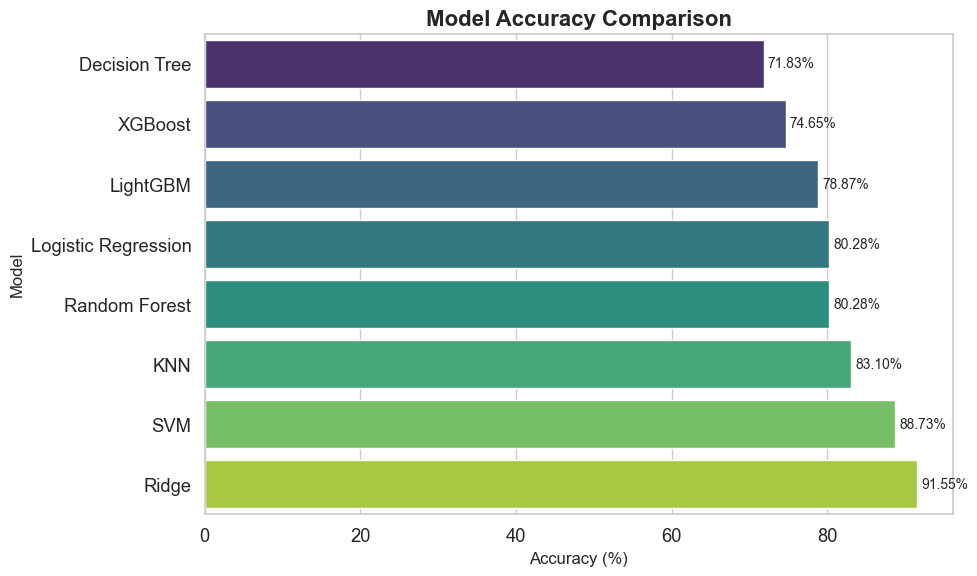

In [70]:
sns.set_theme(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(10,6))
barplot = sns.barplot(
    x="Accuracy (%)", 
    y="Model", 
    data=results_df.sort_values("Accuracy (%)", ascending=True),
    palette="viridis"
)
plt.title("Model Accuracy Comparison", fontsize=16, weight="bold")
plt.xlabel("Accuracy (%)", fontsize=12)
plt.ylabel("Model", fontsize=12)

for p in barplot.patches:
    plt.text(
        p.get_width() + 0.5,      
        p.get_y() + p.get_height()/2,  
        f"{p.get_width():.2f}%", 
        va="center", fontsize=10
    )

plt.tight_layout()
plt.show()

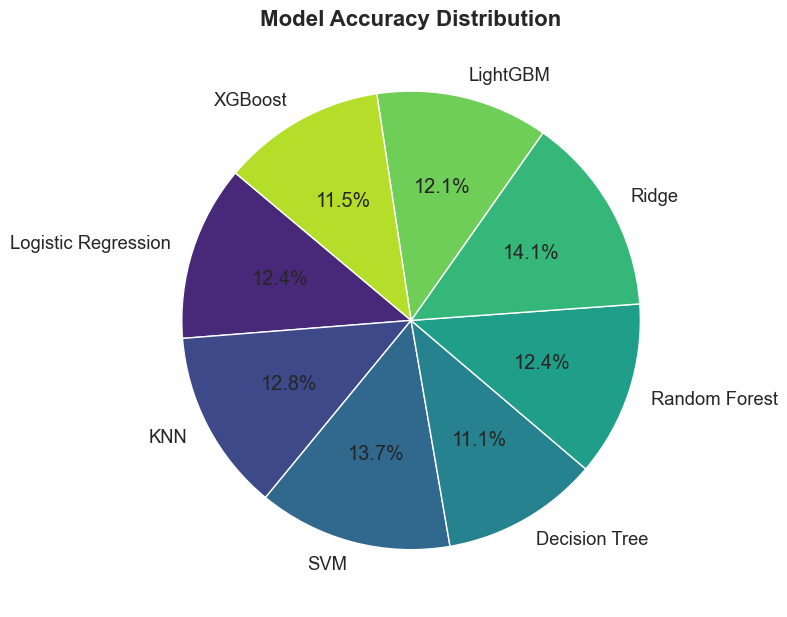

In [71]:
plt.figure(figsize=(8,8))
colors = sns.color_palette("viridis", len(results_df))

plt.pie(
    results_df["Accuracy (%)"],
    labels=results_df["Model"],
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    wedgeprops={"edgecolor":"white","linewidth":1}
)

plt.title("Model Accuracy Distribution", fontsize=16, weight="bold")
plt.tight_layout()
plt.show()

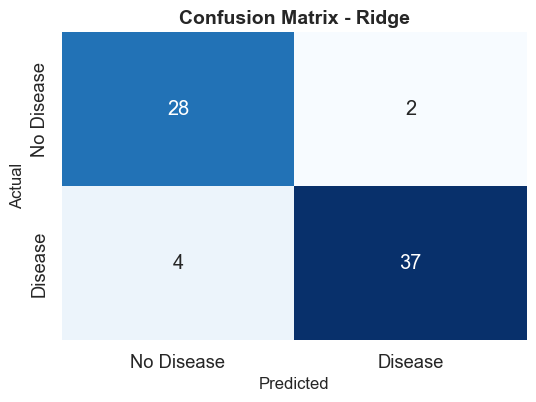

In [146]:
cm_log = confusion_matrix(y_test, y_pred_ridge)

plt.figure(figsize=(6,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.title("Confusion Matrix - Ridge", fontsize=14, weight="bold")
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.show()

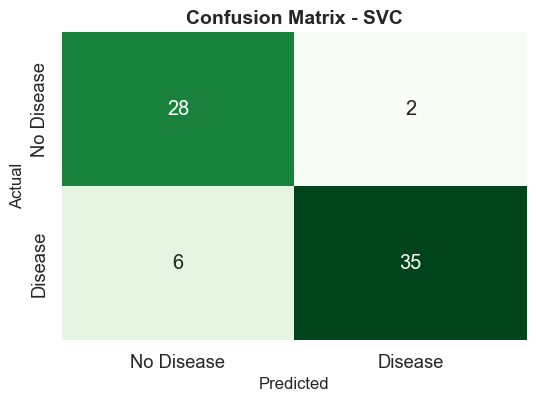

In [149]:
cm_lgbm = confusion_matrix(y_test, y_pred_svc)

plt.figure(figsize=(6,4))
sns.heatmap(cm_lgbm, annot=True, fmt="d", cmap="Greens", cbar=False,
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.title("Confusion Matrix - SVC", fontsize=14, weight="bold")
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.show()